In [66]:
import yfinance as yf
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from copy import deepcopy


In [67]:
def get_price(tick, start='2022-10-01', end=None):
    return yf.Ticker(tick).history(start=start, end=end)['Close']

def get_prices(tickers, start='2022-10-01', end=None):
    df = pd.DataFrame()
    for s in tickers:
        df[s] = get_price(s, start, end)
    return df

feature_stocks = ['tsla','meta','goog','amzn','nflx','gbtc','gdx','intc','dal','c']
predict_stock = 'msft'

# devide train, valid, test dataset
start_train, end_train = '2023-01-01', '2024-06-30'
start_val,   end_val   = '2024-07-01', '2024-10-31'
start_test,  end_test  = '2024-11-01', '2024-12-31'

X_train_df = get_prices(feature_stocks, start=start_train, end=end_train)
y_train_df = get_prices([predict_stock], start=start_train, end=end_train)

X_val_df = get_prices(feature_stocks, start=start_val, end=end_val)
y_val_df = get_prices([predict_stock], start=start_val, end=end_val)

X_test_df = get_prices(feature_stocks, start=start_test, end=end_test)
y_test_df = get_prices([predict_stock], start=start_test, end=end_test)

def align_and_dropna(X_df, y_df):
    df = X_df.join(y_df, how='inner')
    df = df.dropna()
    X = df[X_df.columns].to_numpy(dtype=np.float32)
    y = df[y_df.columns].to_numpy(dtype=np.float32)
    return X, y, df.index

X_train, y_train, idx_train = align_and_dropna(X_train_df, y_train_df)
X_val,   y_val,   idx_val   = align_and_dropna(X_val_df,   y_val_df)
X_test,  y_test,  idx_test  = align_and_dropna(X_test_df,  y_test_df)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)


Train: (374, 10) (374, 1)
Val:   (86, 10) (86, 1)
Test:  (40, 10) (40, 1)


In [68]:
# Normalization with training dataset
mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-8

X_train_n = (X_train - mu) / sigma
X_val_n   = (X_val   - mu) / sigma
X_test_n  = (X_test  - mu) / sigma

y_mu = y_train.mean(axis=0, keepdims=True)
y_sigma = y_train.std(axis=0, keepdims=True) + 1e-8





In [69]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

batch_size = 32

train_loader = DataLoader(StockDataset(X_train_n, y_train), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(StockDataset(X_val_n,   y_val),   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(StockDataset(X_test_n,  y_test),  batch_size=batch_size, shuffle=False, drop_last=False)



In [70]:
class FC5(nn.Module):
    def __init__(self, in_dim, hidden_dim=20, num_hidden=5, out_dim=1):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(num_hidden):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(nn.ReLU())
            d = hidden_dim
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [71]:
def evaluate_mse(model, loader, device):
    model.eval()
    loss_fn = nn.MSELoss(reduction='sum')
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            pred = model(Xb)
            total_loss += loss_fn(pred, yb).item()
            n += yb.shape[0]
    return total_loss / n

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler=None,
    scheduler_type=None,
    epochs=200,
    device='cpu'
):
    loss_fn = nn.MSELoss()
    model = model.to(device)

    train_losses = []
    val_losses = []
    lrs = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        n = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(Xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # scheduler step
            if scheduler is not None and scheduler_type in ["onecycle", "cyclic"]:
                scheduler.step()

            running += loss.item() * yb.shape[0]
            n += yb.shape[0]

        train_mse = running / n
        val_mse = evaluate_mse(model, val_loader, device)


        if scheduler is not None and scheduler_type == "plateau":
            scheduler.step(val_mse)

        train_losses.append(train_mse)
        val_losses.append(val_mse)
        lrs.append(optimizer.param_groups[0]["lr"])

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lrs": lrs
    }


In [72]:
device = "cuda" if torch.cuda.is_available() else "cpu"
in_dim = X_train_n.shape[1]
base_model = FC5(in_dim=in_dim, hidden_dim=20, num_hidden=5, out_dim=1)

epochs = 200
lr = 1e-3

def plot_losses(history_dict, title):
    plt.figure()
    plt.plot(history_dict["train_losses"], label="train")
    plt.plot(history_dict["val_losses"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.show()




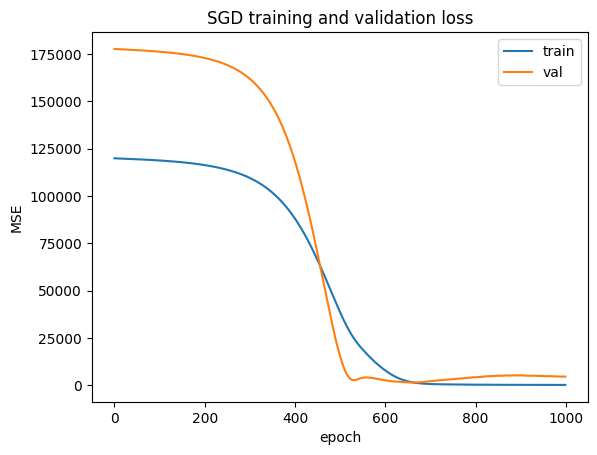

In [73]:
# SGD
m1 = deepcopy(base_model)
opt_sgd = torch.optim.SGD(m1.parameters(), lr=lr)
hist_sgd = train_model(m1, train_loader, val_loader, opt_sgd, scheduler=None, epochs=1000, device=device)
plot_losses(hist_sgd, "SGD training and validation loss")




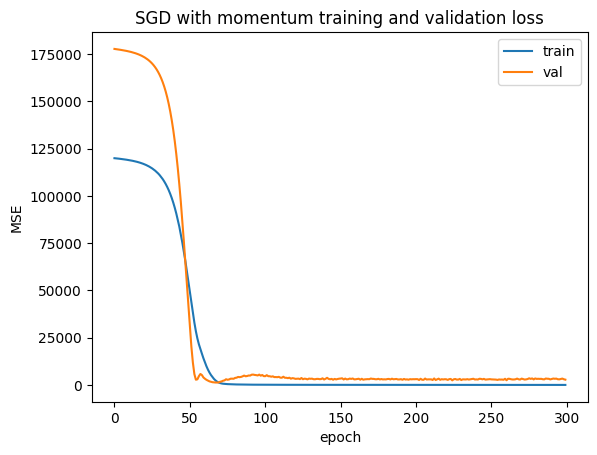

In [74]:
# Momentum
m2 = deepcopy(base_model)
opt_mom = torch.optim.SGD(m2.parameters(), lr=lr, momentum=0.9)
hist_mom = train_model(m2, train_loader, val_loader, opt_mom, scheduler=None, epochs=300, device=device)
plot_losses(hist_mom, "SGD with momentum training and validation loss")


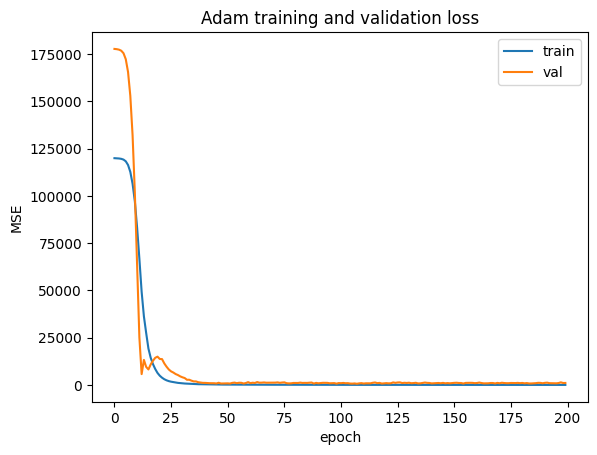

In [75]:
# Adam
m3 = deepcopy(base_model)
opt_adam = torch.optim.Adam(m3.parameters(), lr=lr)
hist_adam = train_model(m3, train_loader, val_loader, opt_adam, scheduler=None, epochs=epochs, device=device)
plot_losses(hist_adam, "Adam training and validation loss")



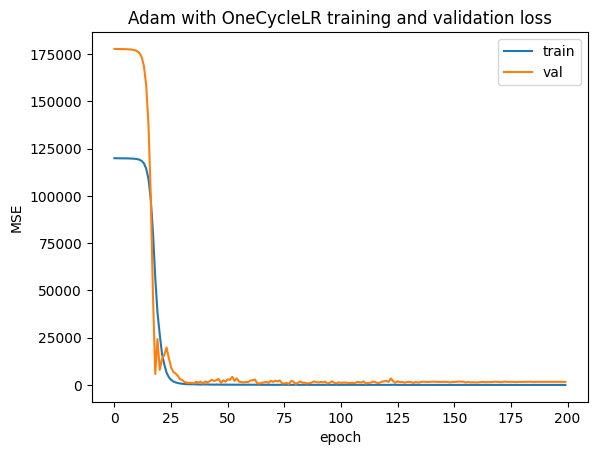

In [76]:
m4 = deepcopy(base_model)
opt = torch.optim.Adam(m4.parameters(), lr=1e-3)

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=5e-3,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch
)

hist_onecycle = train_model(
    m4, train_loader, val_loader, opt,
    scheduler=scheduler, scheduler_type="onecycle",
    epochs=epochs, device=device
)
plot_losses(hist_onecycle, "Adam with OneCycleLR training and validation loss")

# cur_model = hist_onecycle["model"]
# test_mse = evaluate_mse(hist_onecycle, test_loader, device)
# print("Test MSE:", test_mse)

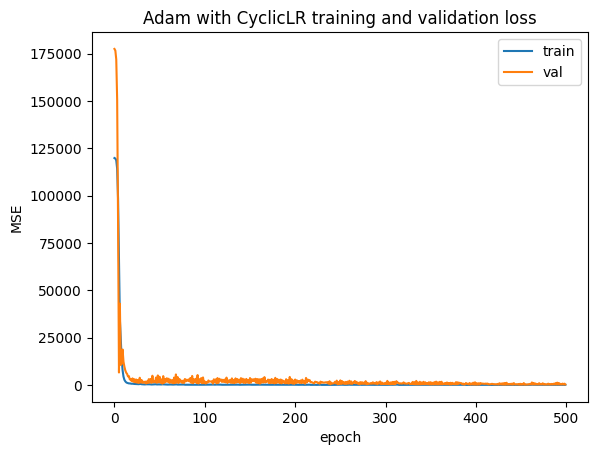

In [77]:
m5 = deepcopy(base_model)
opt = torch.optim.Adam(m5.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CyclicLR(
    opt,
    base_lr=1e-4,
    max_lr=5e-3,
    step_size_up=max(1, steps_per_epoch // 2),
    mode="triangular",
    cycle_momentum=False
)

hist_cyclic = train_model(
    m5, train_loader, val_loader, opt,
    scheduler=scheduler, scheduler_type="cyclic",
    epochs=500, device=device
)
plot_losses(hist_cyclic, "Adam with CyclicLR training and validation loss")




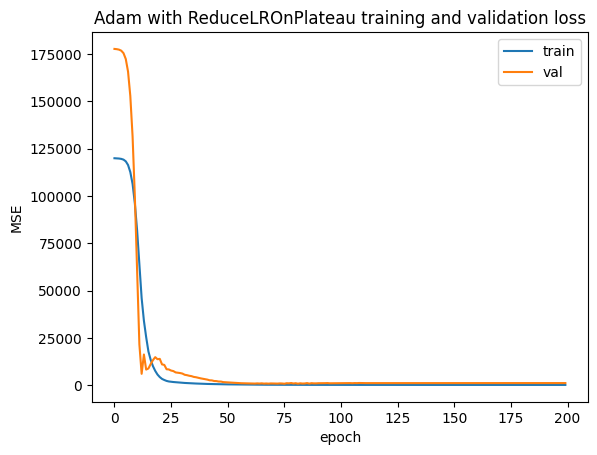

In [78]:
m6 = deepcopy(base_model)
opt = torch.optim.Adam(m6.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    threshold=1e-6
)

hist_plateau = train_model(
    m6, train_loader, val_loader, opt,
    scheduler=scheduler, scheduler_type="plateau",
    epochs=epochs, device=device
)
plot_losses(hist_plateau, "Adam with ReduceLROnPlateau training and validation loss")




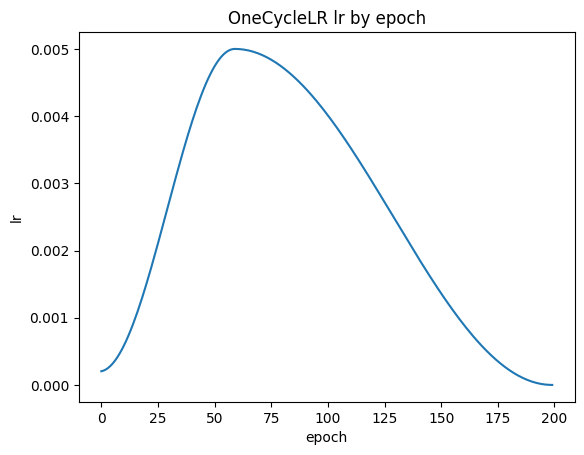

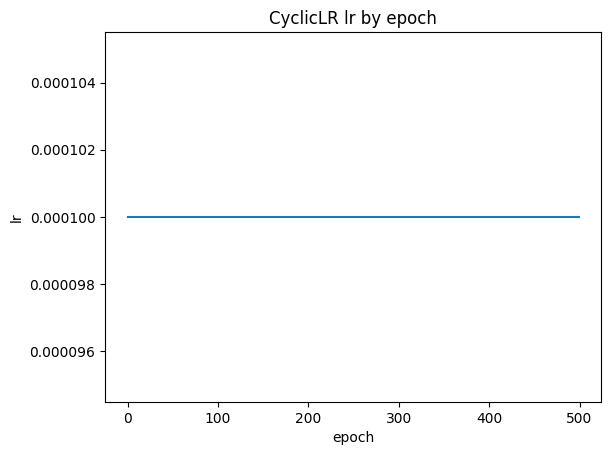

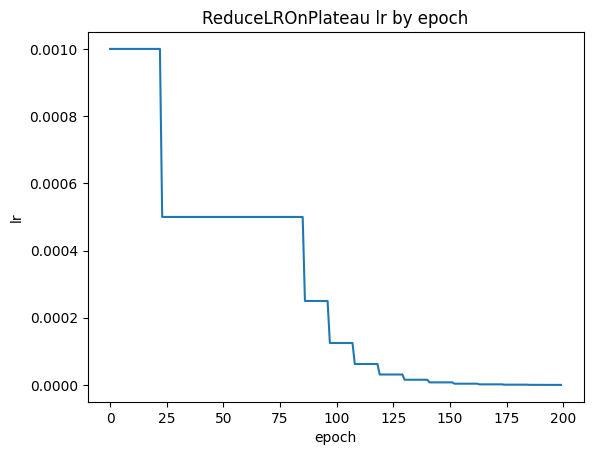

In [79]:
def plot_lr(hist, title):
    plt.figure()
    plt.plot(hist["lrs"])
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title)
    plt.show()

plot_lr(hist_onecycle, "OneCycleLR lr by epoch")
plot_lr(hist_cyclic, "CyclicLR lr by epoch")
plot_lr(hist_plateau, "ReduceLROnPlateau lr by epoch")




In [80]:
onecycle_model = hist_onecycle["model"]
test_mse = evaluate_mse(onecycle_model, test_loader, device)
print("Test MSE for onecycle model:", test_mse)
torch.save(onecycle_model.state_dict(), "onecycle_weights.pth")


cyclic_model = hist_cyclic["model"]
test_mse = evaluate_mse(cyclic_model, test_loader, device)
print("Test MSE for cyclic model:", test_mse)
torch.save(cyclic_model.state_dict(), "cyclic_weights.pth")

plateau_model = hist_onecycle["model"]
test_mse = evaluate_mse(plateau_model, test_loader, device)
print("Test MSE for plateau model:", test_mse)
torch.save(plateau_model.state_dict(), "plateau_weights.pth")


Test MSE for onecycle model: 3241.19833984375
Test MSE for cyclic model: 869.3899658203125
Test MSE for plateau model: 3241.19833984375
